In [16]:
# 02.09.2026 - 20260902c.ipynb: RAMPA MONOTONICZNA.
#
# JEDEN watek. Pytanie postawione przez Maćka po 20260902b: kontrola "bez
# trendu" z tamtego notebooka splaszcza roczne tempo katalogu, a wiec usuwa
# NARAZ dwie rzeczy - zageszczenie sieci sejsmometrow ORAZ hipotetyczna
# modulacje sejsmicznosci przez promieniowanie kosmiczne w skali ~11 lat, o
# ktorej mowi artykul. Zarzut jest sluszny: tamten test nie odroznia tych
# dwoch mozliwosci. Ten notebook je rozdziela.
#
# POMYSL. Modulacja jedenastoletnia jest OSCYLACJA - musi opadac tak samo,
# jak rosnie. Zageszczenie sieci pomiarowej nie opada nigdy. Jesli wiec
# zastapimy roczne tempo katalogu krzywa WYLACZNIE ROSNACA, to z konstrukcji
# usuniemy wszelka oscylacje, a zostawimy caly wzrost. Taki katalog nie moze
# zawierac zadnego sygnalu ~11-letniego po stronie sejsmicznej.
#
# DRABINA CZTERECH WERSJI ROCZNEGO TEMPA (wszystko inne identyczne - ta sama
# laczna liczba zdarzen, ten sam rozklad magnitud rok po roku, te same losowe
# momenty w obrebie roku, ta sama nietknieta strona CR):
#
#   (1) ROCZNIK PRAWDZIWY   - wzrost + schodki + wahania gora-dol.
#       Kontrola wewnetrzna: musi odtworzyc wynik 20260902b.
#   (2) RAMPA SCHODKOWA     - regresja izotoniczna rocznego tempa. Zachowuje
#       wzrost i ostre schodki (w tym skok 1972->1973), usuwa WSZYSTKIE
#       wahania gora-dol. Zero oscylacji z definicji.
#   (3) RAMPA GLADKA        - to samo, ale dodatkowo bez ostrych schodkow
#       (tempo wygladzone oknem 11-letnim, potem zmonotonizowane). Zostaje
#       sam powolny wzrost.
#   (4) TEMPO PLASKIE       - podloga odniesienia, jak fioletowy z 20260902b.
#
# Roznica miedzy (2) a (3) jest osobnym, ostrzejszym pytaniem: czy efekt
# robia KONKRETNE SKOKI katalogu (zmiany sieci/progu/zrodla danych), czy
# wystarczy jakikolwiek powolny wzrost. Mechanizm zdiagnozowany w konsoli
# 02.09 wskazuje na skoki - okno najglebszego minimum ma srodek w lutym 1973,
# czyli dokladnie na skoku 919 -> 4022 zdarzen rocznie.
#
# REGULY ODCZYTU - USTALONE PRZED ZOBACZENIEM WYNIKU:
#   A. Rampa schodkowa odtwarza minima RAZEM Z FAZA -> oscylacja w roczniku
#      nie jest do niczego potrzebna, wiec hipoteza ~11-letnia nie wnosi nic
#      do struktury z Fig.4. Zarzut Maćka zostaje domkniety na korzysc
#      wersji artefaktowej.
#   B. Rampa schodkowa odtwarza, rampa gladka NIE -> przyczyna sa konkretne
#      skoki katalogu, a nie wzrost jako taki. Najostrzejsza mozliwa
#      identyfikacja artefaktu; wskazuje palcem na daty zmian w katalogu.
#   C. Zadna rampa nie odtwarza, a rocznik prawdziwy owszem -> istotna jest
#      NIEMONOTONICZNA (oscylacyjna) skladowa rocznego tempa. Hipoteza
#      artykulu wraca do gry i nastepnym pytaniem jest, czy ta oscylacja
#      jest fizyczna, czy detekcyjna.
#   D. Rocznik prawdziwy tez nie odtwarza -> sprzecznosc z 20260902b,
#      najpierw szukamy bledu, zadnych wnioskow.
#
# CZEGO TEN NOTEBOOK NIE ROZSTRZYGA: jesli wyjdzie C, to nie powie, skad
# bierze sie oscylacja. Do tego sluzy osobny test z rocznikiem o ksztalcie
# katalogu kompletnego (M >= 5,5) przy gestosci M >= 4,0 - patrz dziennik.
#
# STACJA: mosc (stacja z Fig.4 artykulu), jak w 20260902b.
# KOSZT [oszacowanie]: 1 + 4*50 = 201 krzywych po ~3,7 s na 20 rdzeniach,
# czyli okolo 13 minut. Wynik cache'owany razem z konfiguracja.
import json
import os
import sys
import time

import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import binom

sys.path.insert(0, "..")
from mc_parallel import run_jobs_parallel

RESULTS_DIR = "../results"
DATA_DIR = "../data"
USGS_PATH = f"{DATA_DIR}/usgs_data/usgs_m4_1965_2025.csv"
MOSC_PATH = f"{DATA_DIR}/mosc_data.csv"
SILSO_PATH = f"{DATA_DIR}/SN_m_tot_V2.0.csv"

P_DAYS, D_DAYS, M_THRESHOLD, DT_DAYS = 3350, 5, 4.0, 15
PROG_WYSOKOSCI = 5.0
STACJA = "mosc"
N_KRZYWYCH = 50
N_NA_WYKRESIE = 3
ZIARNO_BAZOWE = 20260902
OKNO_WYGLADZANIA = 11     # lat, do rampy gladkiej


def load_mosc():
    df = pd.read_csv(MOSC_PATH)
    df["datetime"] = pd.to_datetime(df["datetime"])
    return df.set_index("datetime").sort_index()["value"]


def load_plamy():
    d = pd.read_csv(SILSO_PATH, sep=";")
    d = d[d["sunspot"] >= 0]
    czas = pd.to_datetime(dict(year=d["rok"], month=d["miesiac"], day=15))
    return pd.Series(d["sunspot"].to_numpy(), index=czas).sort_index() \
             .rolling(13, center=True, min_periods=7).mean()


katalog = pd.read_csv(USGS_PATH, usecols=["time", "mag"])
katalog["time"] = pd.to_datetime(katalog["time"], utc=True).dt.tz_localize(None)
katalog = katalog[katalog["mag"] >= M_THRESHOLD].sort_values("time").reset_index(drop=True)
cr = load_mosc()
plamy = load_plamy()
print(f"Katalog USGS M>={M_THRESHOLD}: {len(katalog)} zdarzen, "
      f"{katalog['time'].min().date()} .. {katalog['time'].max().date()}")
print(f"CR {STACJA}: {len(cr)} pomiarow")

Katalog USGS M>=4.0: 507919 zdarzen, 1965-01-01 .. 2025-01-31
CR mosc: 91824 pomiarow


In [17]:
# Statystyka - wersja szybka, przepisana z 20260902a.ipynb (te same kosze co
# przepis referencyjny z 20260826d.ipynb). Weryfikacja wzgledem wersji
# referencyjnej jest w 20260902a i w results/kalibracja_weryfikacja_statystyki.csv.
_STEP_NS = np.int64(D_DAYS * 86400 * 10 ** 9)
_LAG_NS = np.int64(DT_DAYS * 86400 * 10 ** 9)
_N_KOSZY = int(P_DAYS // D_DAYS)
_OFFSETY = _STEP_NS * np.arange(_N_KOSZY + 1, dtype=np.int64)


def przygotuj_szereg(s):
    t = s.index.values.astype("datetime64[ns]").astype(np.int64)
    v = s.to_numpy(dtype=float)
    ok = ~np.isnan(v)
    return t, np.append(np.where(ok, v, 0.0), 0.0), np.append(ok.astype(np.int64), 0)


def _sumy_koszy(wartosci, idx):
    s = np.add.reduceat(wartosci, idx)[:-1]
    s[idx[1:] == idx[:-1]] = 0
    return s


def _znaki(cr_prep, eq_prep, t0_ns):
    kraw = t0_ns + _OFFSETY
    ct, cv, cn = cr_prep
    ci = np.searchsorted(ct, kraw, side="left")
    suma, liczba = _sumy_koszy(cv, ci), _sumy_koszy(cn, ci)
    with np.errstate(invalid="ignore", divide="ignore"):
        cr_vals = np.where(liczba > 0, suma / np.maximum(liczba, 1), np.nan)
    et, ev, _ = eq_prep
    ei = np.searchsorted(et, kraw + _LAG_NS, side="left")
    sm_vals = _sumy_koszy(ev, ei)
    nCR_i, nCR_im1 = cr_vals[1:], cr_vals[:-1]
    dCR, Sm = nCR_i - nCR_im1, sm_vals[1:]
    A = Sm / np.nanmedian(Sm) - 1
    B = np.abs(dCR) / np.nanmedian(np.abs(dCR)) - 1
    valid = ((A != 0) & (B != 0) & (nCR_i > 0) & (nCR_im1 > 0) & (Sm > 0)
             & ~np.isnan(A) & ~np.isnan(B))
    c = (A * B)[valid]
    Np, Nm = int((c > 0).sum()), int((c < 0).sum())
    return Np, Np + Nm


def skan_krzywej(cr_prep, eq_prep, siatka_ns):
    Np = np.zeros(len(siatka_ns), dtype=np.int64)
    Nv = np.zeros(len(siatka_ns), dtype=np.int64)
    for i, t0_ns in enumerate(siatka_ns):
        Np[i], Nv[i] = _znaki(cr_prep, eq_prep, t0_ns)
    ppdf = np.full(len(siatka_ns), np.nan)
    ok = Nv > 0
    ppdf[ok] = binom.pmf(Np[ok], Nv[ok], 0.5)
    return ppdf


siatka = pd.read_csv(f"{RESULTS_DIR}/finetune_{STACJA}_P3350_d5_dt15_fullhistory.csv",
                     usecols=["t0"], parse_dates=["t0"])["t0"].sort_values().reset_index(drop=True)
siatka_ns = siatka.values.astype("datetime64[ns]").astype(np.int64)
cr_prep = przygotuj_szereg(cr)
KROK_DNI = (siatka.iloc[1] - siatka.iloc[0]) / pd.Timedelta(days=1)
DISTANCE = int(round(P_DAYS / KROK_DNI))
PODPROBKA = int(round(1 / KROK_DNI))
print(f"Siatka t0: {len(siatka)} punktow, krok {KROK_DNI * 24:.0f} h, "
      f"{siatka.iloc[0].date()} .. {siatka.iloc[-1].date()}")

Siatka t0: 74322 punktow, krok 6 h, 1965-01-01 .. 2015-11-15


In [18]:
# CZTERY PROFILE ROCZNEGO TEMPA.
#
# Rok 2025 jest w katalogu niepelny (do 31 stycznia), wiec do DOPASOWANIA
# uzywamy tempa rocznego (liczba zdarzen podzielona przez pokrycie roku), a
# przy generowaniu wracamy do liczby zdarzen mnozac z powrotem przez pokrycie.
# Bez tego dopasowanie widzialoby sztuczny zjazd na koncu i rampa przestalaby
# byc monotoniczna tam, gdzie dane sa po prostu urwane.
_KAT_OD, _KAT_DO = katalog["time"].min(), katalog["time"].max()
_grupy = {int(r): g["mag"].to_numpy() for r, g in katalog.groupby(katalog["time"].dt.year)}
LATA = np.array(sorted(_grupy))
LICZBY = np.array([len(_grupy[r]) for r in LATA], dtype=float)
GRANICE = {}
for r in LATA:
    od = max(pd.Timestamp(year=int(r), month=1, day=1), _KAT_OD)
    do = min(pd.Timestamp(year=int(r) + 1, month=1, day=1), _KAT_DO)
    GRANICE[int(r)] = (od, (do - od).total_seconds())
DLUGOSC_ROKU = np.array([(pd.Timestamp(year=int(r) + 1, month=1, day=1)
                          - pd.Timestamp(year=int(r), month=1, day=1)).total_seconds()
                         for r in LATA])
POKRYCIE = np.array([GRANICE[int(r)][1] for r in LATA]) / DLUGOSC_ROKU
TEMPO = LICZBY / POKRYCIE          # zdarzen na pelny rok


def pava(v):
    """Regresja izotoniczna (pool adjacent violators), wagi jednostkowe.
    Zwraca najblizszy w sensie najmniejszych kwadratow ciag NIEMALEJACY.
    Wlasnosc kluczowa dla tego notebooka: wynik z definicji nie ma zadnej
    skladowej oscylacyjnej, bo nigdy nie opada."""
    poziomy = []
    for x in np.asarray(v, dtype=float):
        poziomy.append([x, 1.0])
        while len(poziomy) > 1 and poziomy[-2][0] > poziomy[-1][0]:
            v2, w2 = poziomy.pop()
            v1, w1 = poziomy.pop()
            poziomy.append([(v1 * w1 + v2 * w2) / (w1 + w2), w1 + w2])
    out = []
    for val, w in poziomy:
        out += [val] * int(round(w))
    return np.array(out[:len(v)])


def do_liczb(tempo_profilu):
    """Profil tempa -> calkowite liczby zdarzen na rok, o sumie DOKLADNIE
    rownej liczbie zdarzen w prawdziwym katalogu (metoda najwiekszych reszt)."""
    surowe = np.asarray(tempo_profilu, dtype=float) * POKRYCIE
    surowe = surowe / surowe.sum() * LICZBY.sum()
    dol = np.floor(surowe).astype(int)
    brak = int(round(LICZBY.sum() - dol.sum()))
    if brak > 0:
        dol[np.argsort(-(surowe - dol))[:brak]] += 1
    return dol


PROFILE = {
    "rocznik_prawdziwy": TEMPO,
    "rampa_schodkowa": pava(TEMPO),
    "rampa_gladka": pava(pd.Series(TEMPO).rolling(
        OKNO_WYGLADZANIA, center=True, min_periods=1).mean().to_numpy()),
    "tempo_plaskie": np.full(len(TEMPO), TEMPO.mean()),
}
LICZBY_PROFILU = {k: do_liczb(v) for k, v in PROFILE.items()}

print(f"{'profil':>20} {'zdarzen':>9} {'spadkow r/r':>12} {'najwiekszy skok':>16} "
      f"{'tempo 05-14 / 70-79':>21}")
for nazwa, tempo in PROFILE.items():
    d = np.diff(tempo)
    r1 = tempo[(LATA >= 1970) & (LATA < 1980)].mean()
    r2 = tempo[(LATA >= 2005) & (LATA < 2015)].mean()
    print(f"{nazwa:>20} {LICZBY_PROFILU[nazwa].sum():9d} {int((d < -1e-9).sum()):12d} "
          f"{(tempo[1:] / np.maximum(tempo[:-1], 1)).max():16.2f} {r2 / r1:21.2f}")
print()
print("Odczyt tabeli: wszystkie cztery wersje maja DOKLADNIE tyle samo zdarzen,")
print("wiec gestosc jest ta sama. Kolumna 'spadkow r/r' pokazuje, ze trzy dolne")
print("profile sa niemalejace, czyli z definicji bez oscylacji. Kolumne")
print("'najwiekszy skok' rozni rampe schodkowa od gladkiej. Ostatnia kolumna")
print("pokazuje, ze caly wieloletni WZROST jest w trzech pierwszych zachowany.")

              profil   zdarzen  spadkow r/r  najwiekszy skok   tempo 05-14 / 70-79
   rocznik_prawdziwy    507919           27             4.38                  4.36
     rampa_schodkowa    507919            0             4.20                  4.28
        rampa_gladka    507919            0             1.48                  4.24
       tempo_plaskie    507919            0             1.00                  1.00

Odczyt tabeli: wszystkie cztery wersje maja DOKLADNIE tyle samo zdarzen,
wiec gestosc jest ta sama. Kolumna 'spadkow r/r' pokazuje, ze trzy dolne
profile sa niemalejace, czyli z definicji bez oscylacji. Kolumne
'najwiekszy skok' rozni rampe schodkowa od gladkiej. Ostatnia kolumna
pokazuje, ze caly wieloletni WZROST jest w trzech pierwszych zachowany.


In [19]:
# Generator katalogu z zadanego profilu rocznych liczb zdarzen.
# Wszystko poza liczba zdarzen w roku jest wspolne dla wszystkich wersji:
#  - magnitudy losowane ze zwracaniem z PRAWDZIWEGO rozkladu magnitud TEGO
#    SAMEGO roku (dzieki temu zmiana profilu nie zmienia przy okazji relacji
#    magnituda-czas, ktora tez ma w katalogu trend),
#  - czasy losowane jednostajnie w obrebie zakresu roku faktycznie pokrytego
#    przez katalog (poprawka niepelnego roku 2025, jak w 20260902a/b).
def zbuduj_katalog(nazwa_profilu, ziarno):
    rng = np.random.default_rng(ziarno)
    liczby = LICZBY_PROFILU[nazwa_profilu]
    czesci = []
    for i, rok in enumerate(LATA):
        n = int(liczby[i])
        if n == 0:
            continue
        poczatek, dlugosc = GRANICE[int(rok)]
        czasy = poczatek + pd.to_timedelta(rng.uniform(0, dlugosc, n), unit="s")
        czesci.append(pd.DataFrame(dict(
            time=czasy, mag=rng.choice(_grupy[int(rok)], size=n, replace=True))))
    s = pd.concat(czesci, ignore_index=True).sort_values("time").reset_index(drop=True)
    s["time"] = s["time"].dt.floor("s").astype("datetime64[us]")
    return s


_probny = zbuduj_katalog("rampa_schodkowa", ZIARNO_BAZOWE)
print(f"Kontrola generatora (rampa schodkowa, jedna realizacja):")
print(f"  zdarzen {len(_probny)} wobec {len(katalog)} w prawdziwym")
print(f"  zakres {_probny['time'].min().date()} .. {_probny['time'].max().date()}")
print(f"  srednia magnituda {_probny['mag'].mean():.4f} wobec {katalog['mag'].mean():.4f}")
_r = _probny.groupby(_probny["time"].dt.year).size()
print(f"  liczba zdarzen w 1972 / 1973: {_r.get(1972, 0)} / {_r.get(1973, 0)} "
      f"(w prawdziwym {int(LICZBY[LATA == 1972][0])} / {int(LICZBY[LATA == 1973][0])})")
print(f"  spadkow rok-do-roku w wygenerowanym katalogu: "
      f"{int((np.diff(_r.to_numpy()[:-1]) < 0).sum())} (poza rokiem niepelnym 2025)")

Kontrola generatora (rampa schodkowa, jedna realizacja):
  zdarzen 507919 wobec 507919 w prawdziwym
  zakres 1965-01-01 .. 2025-01-31
  srednia magnituda 4.6022 wobec 4.6015
  liczba zdarzen w 1972 / 1973: 958 / 4022 (w prawdziwym 919 / 4022)
  spadkow rok-do-roku w wygenerowanym katalogu: 0 (poza rokiem niepelnym 2025)


In [20]:
# Skan wszystkich krzywych.
SCIEZKA_KRZYWE = f"{RESULTS_DIR}/rampa_krzywe_{STACJA}.csv"
SCIEZKA_MINIMA = f"{RESULTS_DIR}/rampa_minima_{STACJA}.csv"
SCIEZKA_KONFIG = f"{RESULTS_DIR}/rampa_config_{STACJA}.json"
PRZELICZ_OD_NOWA = False
WERSJE = ["rocznik_prawdziwy", "rampa_schodkowa", "rampa_gladka", "tempo_plaskie"]


def biezaca_konfiguracja():
    return dict(STACJA=STACJA, P_DAYS=P_DAYS, D_DAYS=D_DAYS, DT_DAYS=DT_DAYS,
                M_THRESHOLD=M_THRESHOLD, PROG_WYSOKOSCI=PROG_WYSOKOSCI,
                DISTANCE=DISTANCE, PODPROBKA=PODPROBKA, N_KRZYWYCH=N_KRZYWYCH,
                ZIARNO_BAZOWE=ZIARNO_BAZOWE, OKNO_WYGLADZANIA=OKNO_WYGLADZANIA,
                WERSJE=WERSJE, katalog_n=int(len(katalog)),
                katalog_zakres=[str(_KAT_OD), str(_KAT_DO)],
                profile={k: [float(v[0]), float(v[len(v) // 2]), float(v[-1])]
                         for k, v in PROFILE.items()},
                siatka=[str(siatka.iloc[0]), str(siatka.iloc[-1]), int(len(siatka))])


def zadanie(job):
    typ, ziarno = job
    kat = katalog if typ == "prawdziwy" else zbuduj_katalog(typ, ziarno)
    ppdf = skan_krzywej(cr_prep,
                        przygotuj_szereg(kat.set_index("time")["mag"].sort_index()),
                        siatka_ns)
    y = -np.log10(ppdf)
    piki, _ = find_peaks(np.nan_to_num(y, nan=-1.0), height=PROG_WYSOKOSCI, distance=DISTANCE)
    return dict(typ=typ, ziarno=int(ziarno), n_minimow=int(len(piki)),
                minima_t0=";".join(str(d) for d in siatka.iloc[piki]),
                minima_wys=";".join(f"{v:.4f}" for v in y[piki]),
                max_krzywej=float(np.nanmax(y)),
                krzywa=[float(v) for v in y[::PODPROBKA]])


zadania = [("prawdziwy", 0)]
for i, w in enumerate(WERSJE):
    zadania += [(w, ZIARNO_BAZOWE + 1000 * i + j) for j in range(N_KRZYWYCH)]

wczytano = False
if not PRZELICZ_OD_NOWA and all(os.path.exists(p) for p in
                                (SCIEZKA_KRZYWE, SCIEZKA_MINIMA, SCIEZKA_KONFIG)):
    if json.load(open(SCIEZKA_KONFIG)) == biezaca_konfiguracja():
        krzywe = pd.read_csv(SCIEZKA_KRZYWE, parse_dates=["srodek_okna"])
        minima_tab = pd.read_csv(SCIEZKA_MINIMA)
        if len(minima_tab) == len(zadania):
            wczytano = True
            print(f"WCZYTANO gotowe krzywe z {SCIEZKA_KRZYWE} - nic nie liczono.")
    if not wczytano:
        print("Zapisane krzywe nie pasuja do biezacej konfiguracji - liczymy od nowa.")

if not wczytano:
    print(f"Skan: {len(zadania)} krzywych x {len(siatka)} punktow t0.")
    start = time.time()
    surowe = run_jobs_parallel(zadanie, zadania, opis="krzywych", raport_co=20)
    print(f"Czas calkowity: {(time.time() - start) / 60:.1f} min")
    srodki = siatka.iloc[::PODPROBKA].reset_index(drop=True) + pd.Timedelta(days=P_DAYS / 2)
    kolumny = {"srodek_okna": srodki}
    for r in surowe.itertuples():
        kolumny[f"{r.typ}__{r.ziarno}"] = r.krzywa
    krzywe = pd.DataFrame(kolumny)
    krzywe.to_csv(SCIEZKA_KRZYWE, index=False)
    minima_tab = surowe.drop(columns=["krzywa"])
    minima_tab.to_csv(SCIEZKA_MINIMA, index=False)
    json.dump(biezaca_konfiguracja(), open(SCIEZKA_KONFIG, "w"), indent=1)
    print(f"Zapisano {SCIEZKA_KRZYWE} i {SCIEZKA_MINIMA}")

# Kolumny sortowane PO ZIARNIE, nie po kolejnosci ukonczenia. Zadania wracaja
# z puli procesow w kolejnosci, w jakiej sie policzyly, wiec bez tego panele
# podgladowe pokazywalyby za kazdym uruchomieniem inne realizacje.
KOL = {w: sorted([c for c in krzywe.columns if c.startswith(f"{w}__")],
                 key=lambda c: int(c.split("__")[1])) for w in WERSJE}
KOL_PRAWDZIWA = "prawdziwy__0"
for w in WERSJE:
    print(f"  {w}: {len(KOL[w])} krzywych")

WCZYTANO gotowe krzywe z ../results/rampa_krzywe_mosc.csv - nic nie liczono.
  rocznik_prawdziwy: 50 krzywych
  rampa_schodkowa: 50 krzywych
  rampa_gladka: 50 krzywych
  tempo_plaskie: 50 krzywych


In [21]:
# LICZBY: minima w kazdej wersji rocznika.
def rozbij(w):
    return [pd.Timestamp(x) for x in w.split(";")] if isinstance(w, str) and w else []


minima_tab["daty"] = minima_tab["minima_t0"].apply(rozbij)
praw = minima_tab[minima_tab.typ == "prawdziwy"].iloc[0]
daty_praw = praw["daty"]

print("KATALOG PRAWDZIWY (odniesienie)")
print(f"  minimow: {praw['n_minimow']}, najglebsze {praw['max_krzywej']:.2f}")
print(f"  daty t0: {', '.join(str(d.date()) for d in daty_praw)}")
print()
OPISY = {"rocznik_prawdziwy": "ROCZNIK PRAWDZIWY (kontrola: ma odtworzyc 20260902b)",
         "rampa_schodkowa": "RAMPA SCHODKOWA (monotoniczna, ze skokami)",
         "rampa_gladka": "RAMPA GLADKA (monotoniczna, bez skokow)",
         "tempo_plaskie": "TEMPO PLASKIE (podloga odniesienia)"}
for w in WERSJE:
    g = minima_tab[minima_tab.typ == w]
    liczby = g["n_minimow"].value_counts().sort_index()
    print(OPISY[w])
    print(f"  minimow w {len(g)} realizacjach: "
          f"{', '.join(f'{k} w {v} realizacjach' for k, v in liczby.items())}"
          f"  (srednio {g['n_minimow'].mean():.2f})")
    print(f"  najglebsze minimum: mediana {g['max_krzywej'].median():.2f}, "
          f"maksimum {g['max_krzywej'].max():.2f}")
    print("  zgodnosc dat z minimami katalogu prawdziwego (promien 1 roku):")
    for d in daty_praw:
        traf = sum(any(abs((x - d).days) <= 365 for x in lista) for lista in g["daty"])
        print(f"    {d.date()}: {traf:3d}/{len(g)}  ({100 * traf / len(g):3.0f}%)")
    print()

KATALOG PRAWDZIWY (odniesienie)
  minimow: 5, najglebsze 9.72
  daty t0: 1968-07-12, 1978-05-24, 1988-08-30, 1999-03-10, 2008-09-27

ROCZNIK PRAWDZIWY (kontrola: ma odtworzyc 20260902b)
  minimow w 50 realizacjach: 4 w 5 realizacjach, 5 w 45 realizacjach  (srednio 4.90)
  najglebsze minimum: mediana 12.00, maksimum 14.58
  zgodnosc dat z minimami katalogu prawdziwego (promien 1 roku):
    1968-07-12:  50/50  (100%)
    1978-05-24:  50/50  (100%)
    1988-08-30:  50/50  (100%)
    1999-03-10:  50/50  (100%)
    2008-09-27:   6/50  ( 12%)

RAMPA SCHODKOWA (monotoniczna, ze skokami)
  minimow w 50 realizacjach: 4 w 46 realizacjach, 5 w 4 realizacjach  (srednio 4.08)
  najglebsze minimum: mediana 11.12, maksimum 14.58
  zgodnosc dat z minimami katalogu prawdziwego (promien 1 roku):
    1968-07-12:  50/50  (100%)
    1978-05-24:  50/50  (100%)
    1988-08-30:  50/50  (100%)
    1999-03-10:  23/50  ( 46%)
    2008-09-27:   2/50  (  4%)

RAMPA GLADKA (monotoniczna, bez skokow)
  minimow w 50 

Zapisano ../results/rampa_1_profile_tempa.png


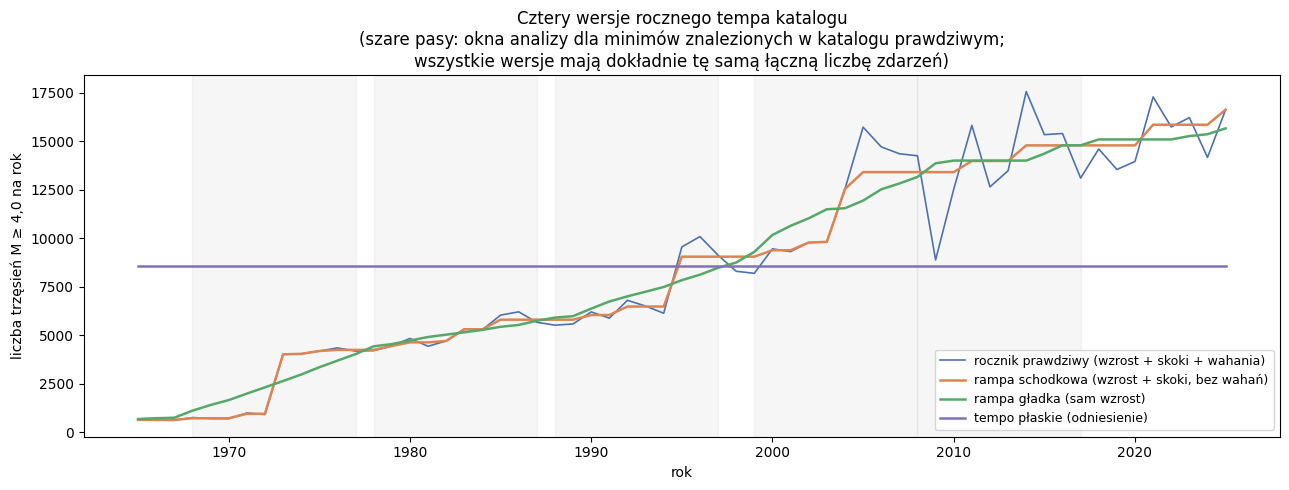

In [22]:
# WYKRES 1 (jedno kodowanie: wysokosc krzywej) - CO WLASCIWIE ZMIENIAMY.
# Bez tego wykresu cala reszta notebooka jest nieczytelna: to on pokazuje, ze
# rozne wersje katalogu roznia sie WYLACZNIE przebiegiem rocznego tempa.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))
KOLORY = {"rocznik_prawdziwy": "#4C72B0", "rampa_schodkowa": "#DD8452",
          "rampa_gladka": "#55A868", "tempo_plaskie": "#8172B3"}
ETYKIETY = {"rocznik_prawdziwy": "rocznik prawdziwy (wzrost + skoki + wahania)",
            "rampa_schodkowa": "rampa schodkowa (wzrost + skoki, bez wahań)",
            "rampa_gladka": "rampa gładka (sam wzrost)",
            "tempo_plaskie": "tempo płaskie (odniesienie)"}
for w in WERSJE:
    ax.plot(LATA, PROFILE[w], color=KOLORY[w], lw=1.8 if w != "rocznik_prawdziwy" else 1.2,
            label=ETYKIETY[w])
for d in daty_praw:
    ax.axvspan(d.year, (d + pd.Timedelta(days=P_DAYS)).year, color="gray", alpha=0.07)
ax.set_xlabel("rok")
ax.set_ylabel("liczba trzęsień M ≥ 4,0 na rok")
ax.set_title("Cztery wersje rocznego tempa katalogu\n"
             "(szare pasy: okna analizy dla minimów znalezionych w katalogu prawdziwym;\n"
             "wszystkie wersje mają dokładnie tę samą łączną liczbę zdarzeń)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/rampa_1_profile_tempa.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/rampa_1_profile_tempa.png")

Zapisano ../results/rampa_2_fig4_prawdziwy.png


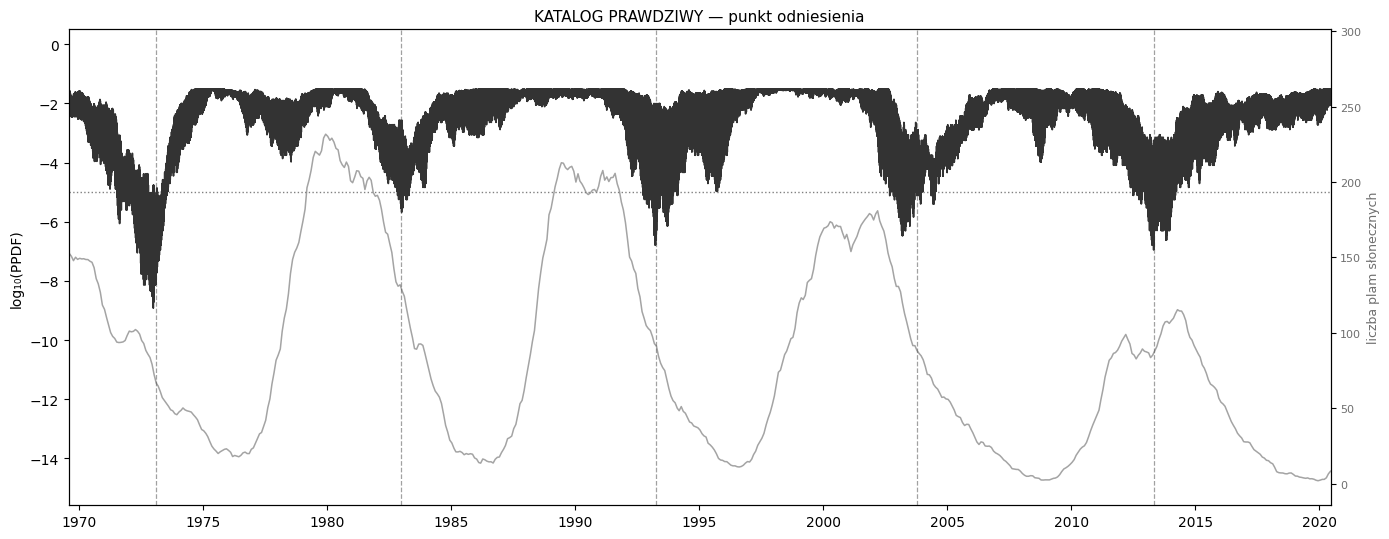

In [23]:
# WYKRES 2 - Fig.4 dla katalogu PRAWDZIWEGO. Osobny plik, pelna szerokosc.
#
# Rozbicie drabiny na osobne pliki (zamiast jednej strony z 13 panelami) po
# uwadze Macka z 02.09: przy 13 panelach kazdy mial 2,3 cala wysokosci i
# ksztaltu krzywej nie dalo sie z niego odczytac. A to wlasnie KSZTALT jest tu
# informacja jakosciowa - detekcja pikow sprowadza kazda krzywa do trzech liczb
# i z definicji nie widzi ani szerokosci niecek, ani tego, co dzieje sie miedzy
# minimami, czyli 95% przebiegu.
#
# Wszystkie pliki maja IDENTYCZNE osie (X_LIM, Y_LIM ustalone raz, na podstawie
# wszystkich krzywych naraz), wiec mozna je przegladac jeden po drugim jak
# klatki i porownywac bezposrednio.
import matplotlib.pyplot as plt

wszystkie_kol = [KOL_PRAWDZIWA] + [c for w in WERSJE for c in KOL[w]]
X_LIM = (krzywe["srodek_okna"].min(), krzywe["srodek_okna"].max())
Y_LIM = (-float(np.nanmax(krzywe[wszystkie_kol].to_numpy())) - 1, 0.5)


def szkielet_fig4(ax, tytul):
    """Osie w konwencji Fig.4 artykulu: X to SRODEK okna analizy, Y to
    log10(PPDF) (minima w dol), plamy sloneczne na osi pomocniczej."""
    ax.set_xlim(*X_LIM)
    ax.set_ylim(*Y_LIM)
    ax.axhline(-PROG_WYSOKOSCI, color="gray", ls=":", lw=1)
    ax.set_ylabel("log₁₀(PPDF)")
    ax.set_title(tytul, fontsize=11)
    # Plamy sloneczne i linie odniesienia rysowane SZAROSCIA, nie kolorem: sa
    # tlem, a nie seria danych, i musza byc odrozniane od kazdej z czterech
    # krzywych. W pierwszej wersji plamy mialy ten sam pomaranczowy co rampa
    # schodkowa i obie krzywe sie zlewaly.
    ax2 = ax.twinx()
    ax2.plot(plamy.index, plamy.to_numpy(), color="#9A9A9A", lw=1.1, alpha=0.9)
    ax2.set_ylabel("liczba plam słonecznych", color="#6E6E6E", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#6E6E6E", labelsize=8)
    ax2.set_zorder(0)
    ax.set_zorder(1)
    ax.patch.set_visible(False)
    for d in daty_praw:
        ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#555555", ls="--",
                   lw=0.9, alpha=0.55)
    return ax2


def rysuj_wersje(w, plik):
    """Jedna wersja rocznika = jeden plik, N_NA_WYKRESIE realizacji w panelach
    o czytelnej wysokosci. Realizacje sa pierwszymi WEDLUG ZIARNA, wiec te same
    przy kazdym uruchomieniu; pelna statystyka po 50 realizacjach jest w
    tabelach i na wykresie polozen minimow."""
    fig, osie = plt.subplots(N_NA_WYKRESIE, 1, figsize=(14, 3.4 * N_NA_WYKRESIE),
                             sharex=True)
    for j, (ax, kol) in enumerate(zip(np.atleast_1d(osie), KOL[w][:N_NA_WYKRESIE])):
        szkielet_fig4(ax, f"{ETYKIETY[w]} — realizacja {j + 1} (ziarno {kol.split('__')[1]})")
        ax.plot(krzywe["srodek_okna"], -krzywe[kol], color=KOLORY[w], lw=1.1)
    fig.suptitle(f"Fig. 4 dla katalogu: {ETYKIETY[w]}\n"
                 f"(linie przerywane: minima katalogu prawdziwego; szara: "
                 f"plamy słoneczne; osie identyczne we wszystkich plikach)",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/{plik}", dpi=150)
    print(f"Zapisano {RESULTS_DIR}/{plik}")


fig, ax = plt.subplots(figsize=(14, 5.5))
szkielet_fig4(ax, "KATALOG PRAWDZIWY — punkt odniesienia")
ax.plot(krzywe["srodek_okna"], -krzywe[KOL_PRAWDZIWA], color="#333333", lw=1.2)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/rampa_2_fig4_prawdziwy.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/rampa_2_fig4_prawdziwy.png")

Zapisano ../results/rampa_3_fig4_rocznik_prawdziwy.png


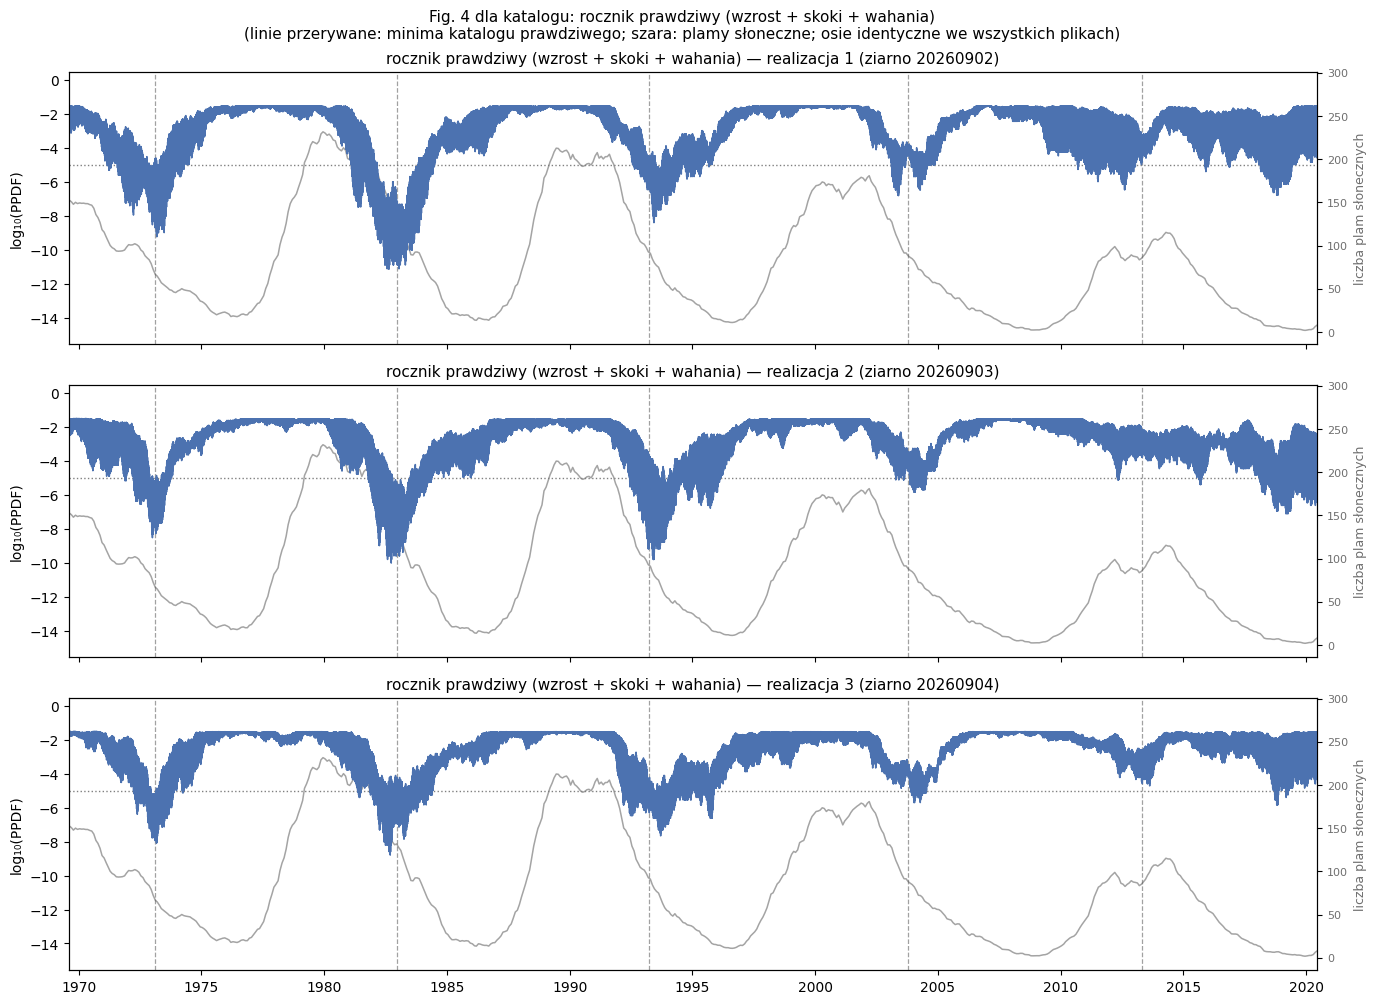

In [24]:
# WYKRES 3 - rocznik prawdziwy (kontrola wewnetrzna: ma odtworzyc 20260902b).
rysuj_wersje("rocznik_prawdziwy", "rampa_3_fig4_rocznik_prawdziwy.png")

Zapisano ../results/rampa_4_fig4_rampa_schodkowa.png


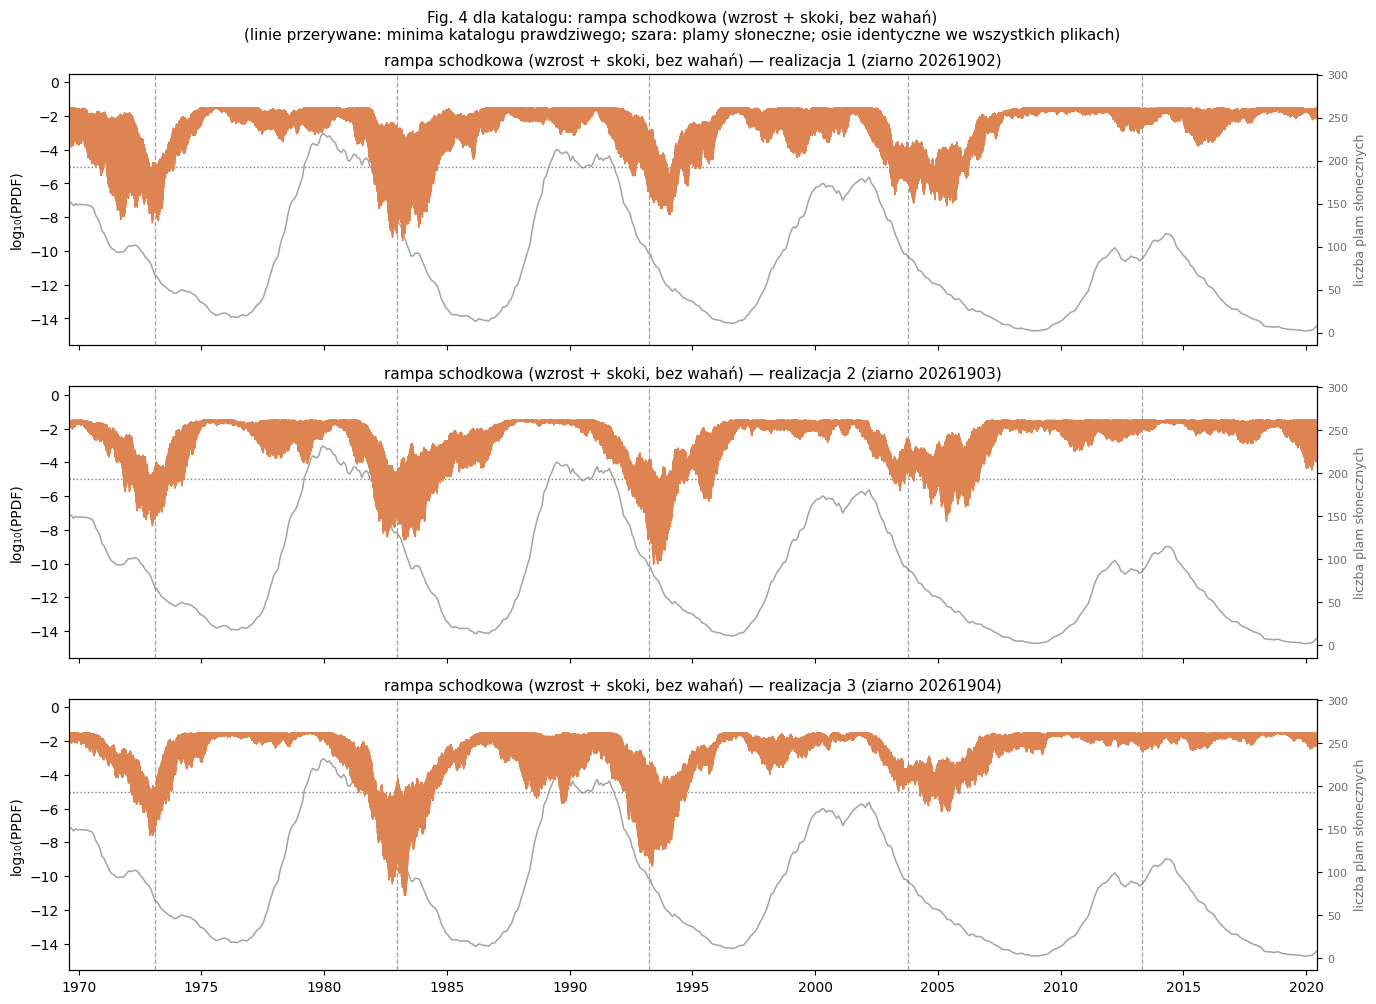

In [25]:
# WYKRES 4 - rampa schodkowa: monotoniczna, ze skokami, ZERO oscylacji.
rysuj_wersje("rampa_schodkowa", "rampa_4_fig4_rampa_schodkowa.png")

Zapisano ../results/rampa_5_fig4_rampa_gladka.png


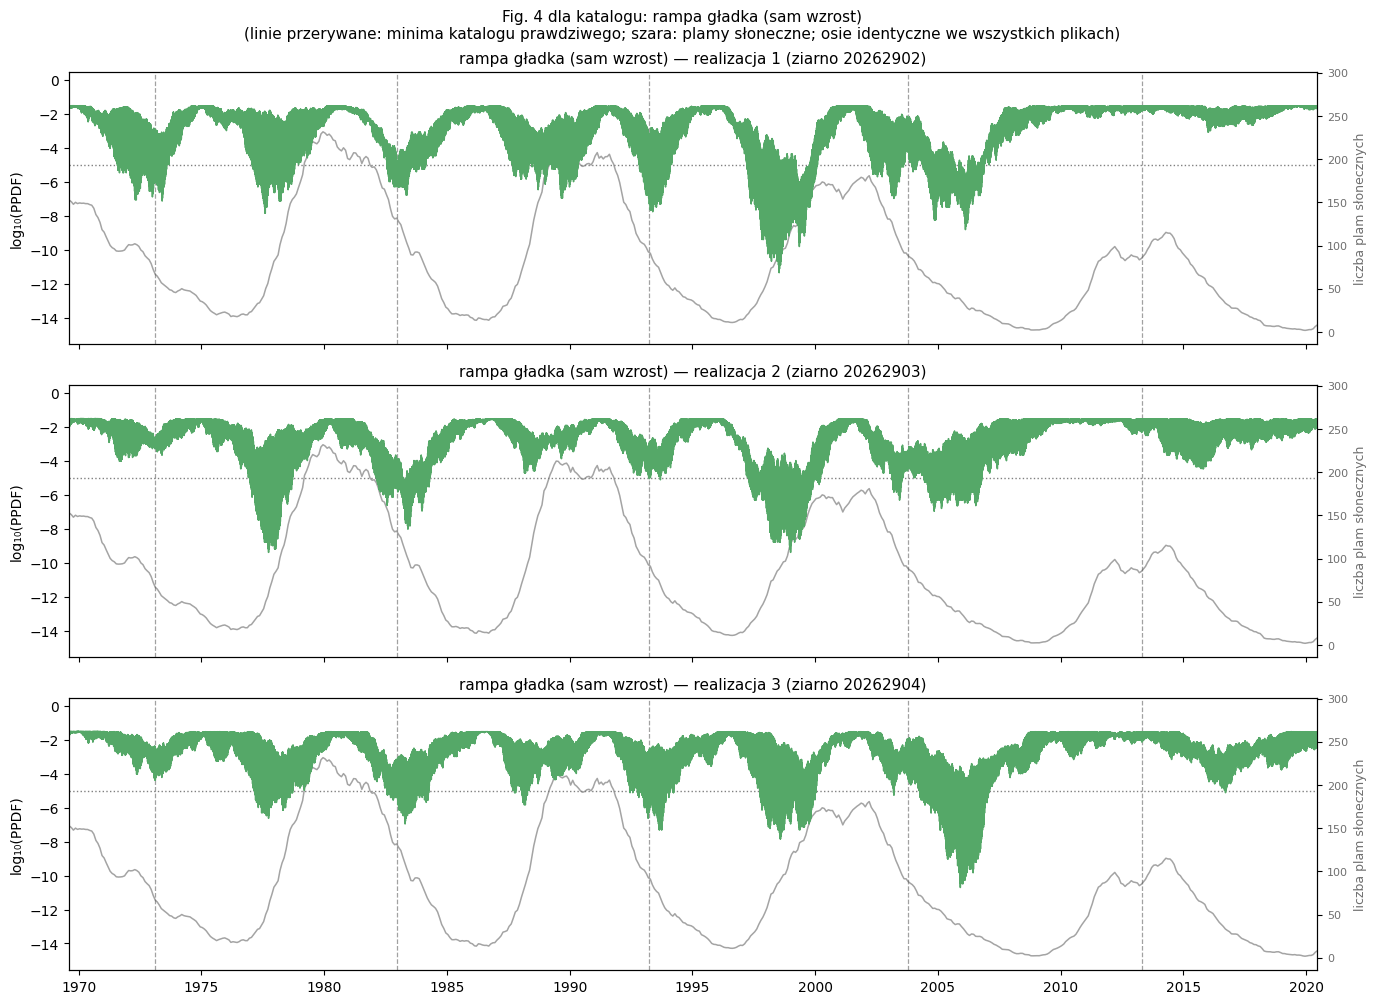

In [26]:
# WYKRES 5 - rampa gladka: monotoniczna, bez ostrych skokow.
rysuj_wersje("rampa_gladka", "rampa_5_fig4_rampa_gladka.png")

Zapisano ../results/rampa_6_fig4_tempo_plaskie.png


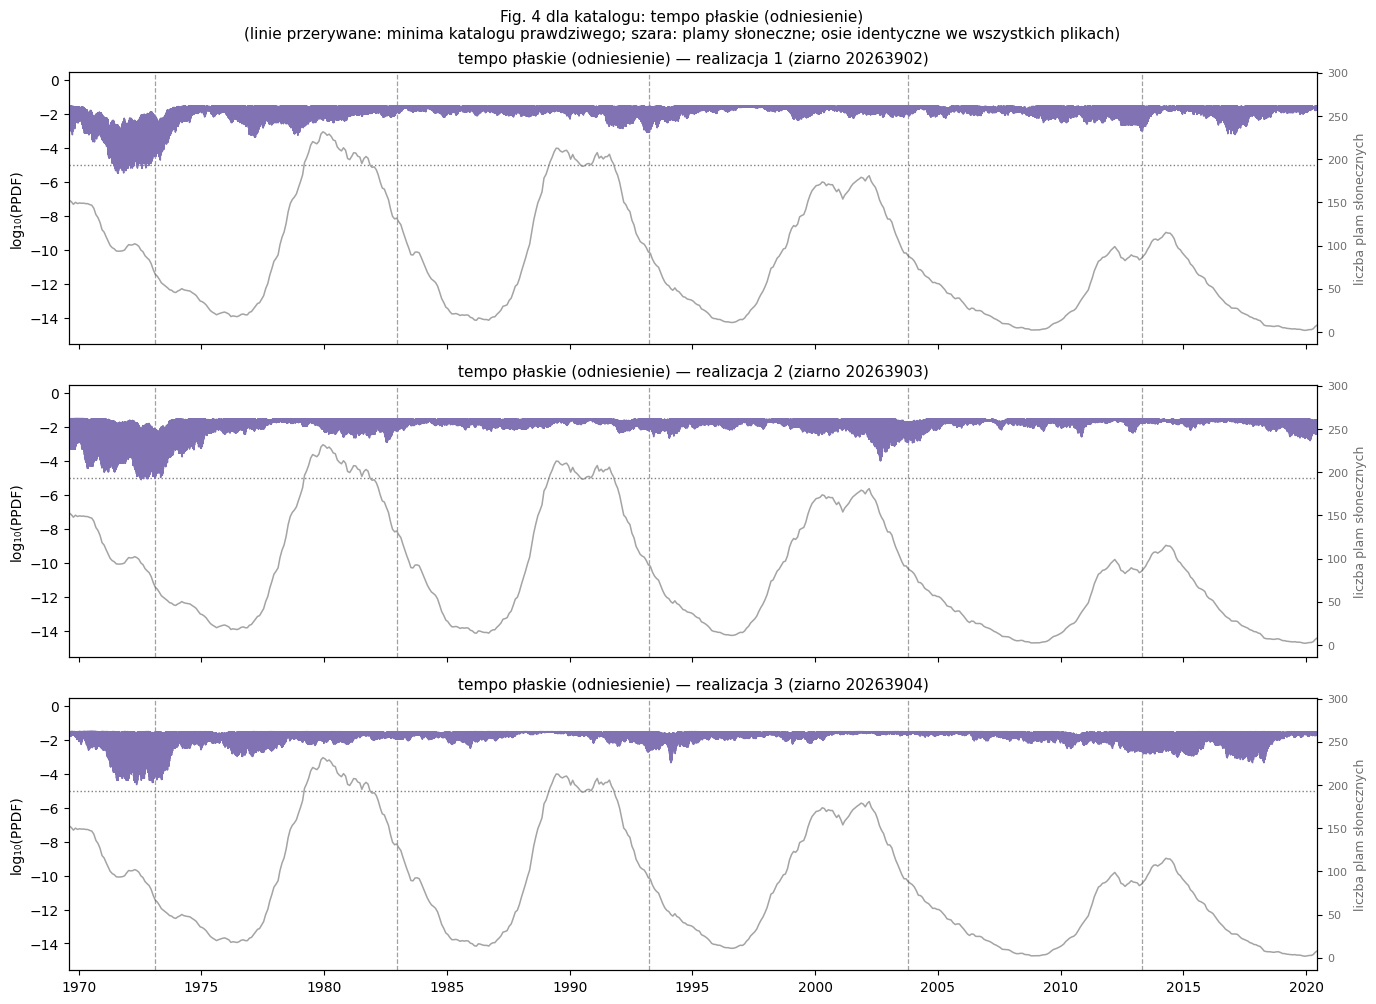

In [27]:
# WYKRES 6 - tempo plaskie: podloga odniesienia.
rysuj_wersje("tempo_plaskie", "rampa_6_fig4_tempo_plaskie.png")

Zapisano ../results/rampa_7_daty.png


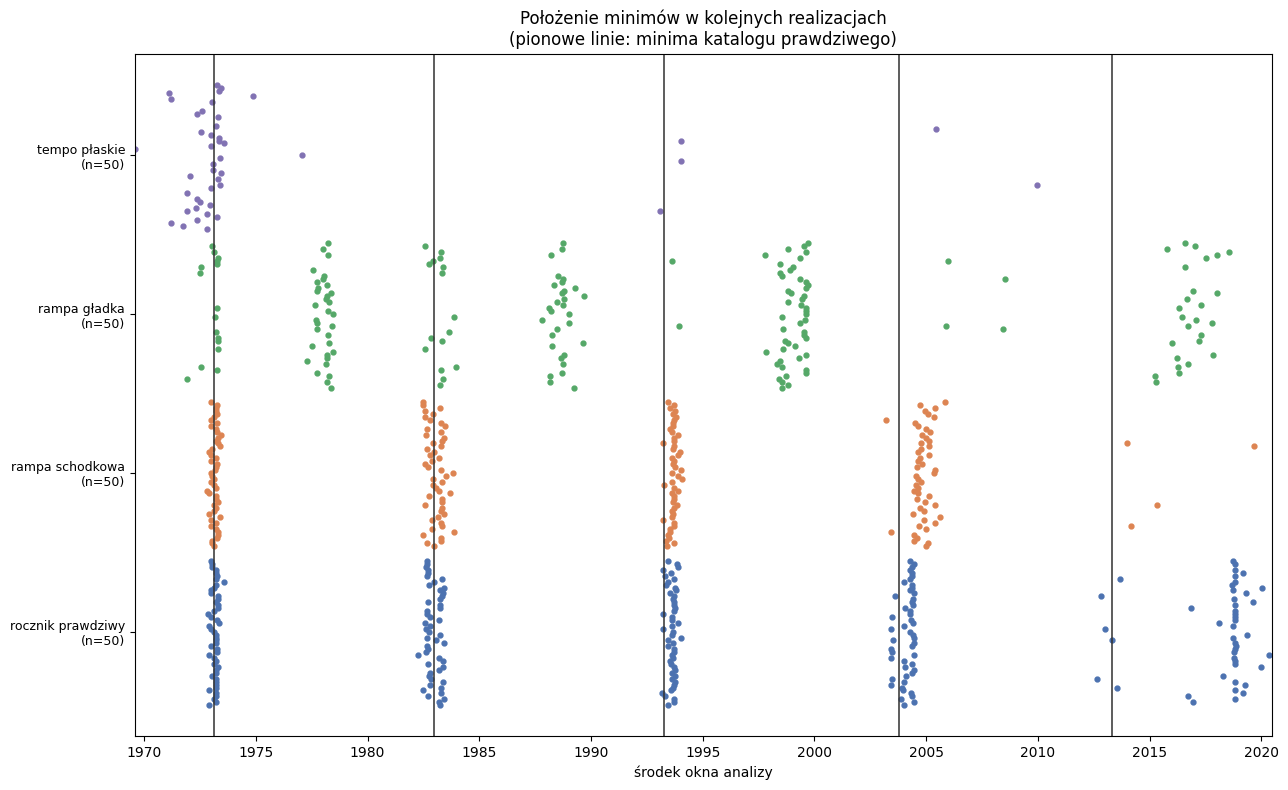

In [28]:
# WYKRES 6 (jedno kodowanie: polozenie znacznika na osi czasu) - GDZIE
# wypadaja minima w kazdej wersji. Ten wykres odpowiada na pytanie o FAZE,
# ktore jest tu wazniejsze niz sama liczba minimow.
fig, ax = plt.subplots(figsize=(13, 8))
y0 = 0
etykiety_y, pozycje_y = [], []
for w in WERSJE:
    g = minima_tab[minima_tab.typ == w].reset_index(drop=True)
    for i, r in g.iterrows():
        ax.plot([d + pd.Timedelta(days=P_DAYS / 2) for d in r["daty"]],
                [y0 + i] * len(r["daty"]), "o", color=KOLORY[w], ms=3.5)
    etykiety_y.append(ETYKIETY[w].split(" (")[0] + f"\n(n={len(g)})")
    pozycje_y.append(y0 + len(g) / 2)
    y0 += len(g) + 4
for d in daty_praw:
    ax.axvline(d + pd.Timedelta(days=P_DAYS / 2), color="#333333", lw=1.4, alpha=0.8)
ax.set_xlim(*X_LIM)
ax.set_yticks(pozycje_y)
ax.set_yticklabels(etykiety_y, fontsize=9)
ax.set_xlabel("środek okna analizy")
ax.set_title("Położenie minimów w kolejnych realizacjach\n"
             "(pionowe linie: minima katalogu prawdziwego)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/rampa_7_daty.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/rampa_7_daty.png")

Minima cyklu slonecznego wykryte w danych SILSO (25): 1755-02-15, 1766-05-15, 1775-06-15, 1784-08-15, 1798-04-15, 1810-08-15, 1823-05-15, 1833-10-15, 1843-07-15, 1856-01-15, 1867-03-15, 1878-10-15, 1888-12-15, 1902-01-15, 1913-07-15, 1923-07-15, 1933-09-15, 1944-03-15, 1954-04-15, 1964-10-15, 1976-06-15, 1986-03-15, 1996-08-15, 2008-11-15, 2019-12-15
Srednia faza maksimum cyklu: 0.42 (czyli maksimum plam wypada w 42% drogi miedzy minimami)

Zapisano ../results/rampa_8_faza_cyklu.png

Fazy minimow katalogu prawdziwego:
  1968-07-12 (środek okna 1973-02-11): faza 0.71
  1978-05-24 (środek okna 1982-12-24): faza 0.67
  1988-08-30 (środek okna 1993-04-01): faza 0.68
  1999-03-10 (środek okna 2003-10-10): faza 0.58
  2008-09-27 (środek okna 2013-04-29): faza 0.40


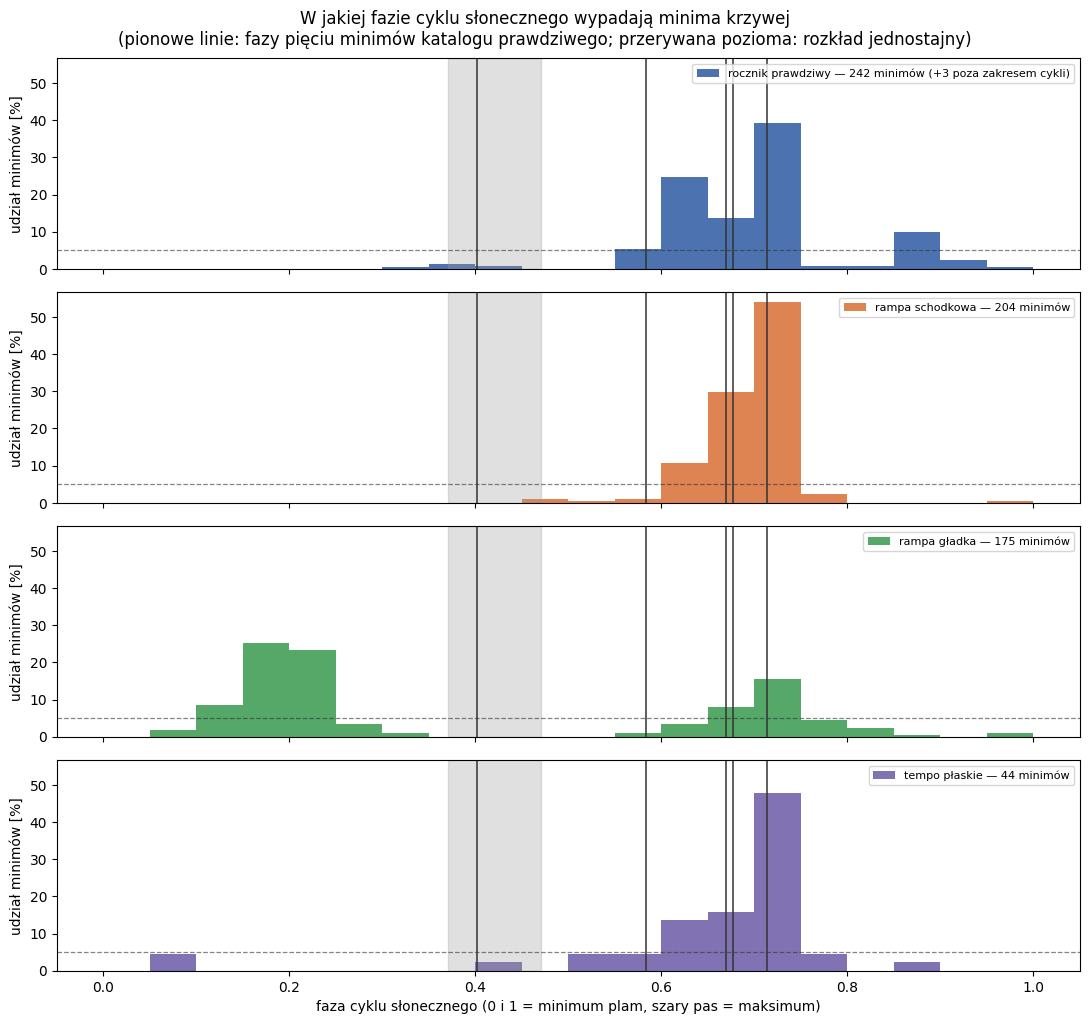

In [29]:
# WYKRES 8 (jedno kodowanie: wysokosc slupka) - W JAKIEJ FAZIE CYKLU SLONECZNEGO
# WYPADAJA MINIMA.
#
# Wykres dodany 02.09 po uwadze Macka, ze dotychczasowe tabele porownywaly
# polozenia minimow WYLACZNIE MIEDZY SOBA ("czy surogat trafia w te same daty co
# katalog prawdziwy"), podczas gdy teza artykulu dotyczy ich polozenia WZGLEDEM
# CYKLU SLONECZNEGO. To sa dwa rozne pytania i dotad zadawalismy tylko pierwsze.
#
# Faza liczona miedzy kolejnymi MINIMAMI wygladzonej liczby plam slonecznych:
# 0 i 1 to minimum cyklu, maksimum wypada mniej wiecej w polowie (dokladna
# srednia pozycja wyliczona z danych i zaznaczona na wykresie). Dla kazdego
# minimum krzywej bierzemy faze w SRODKU jego okna analizy - tej samej
# wielkosci, ktora jest na osi X wykresow Fig.4.
#
# Uwaga interpretacyjna: minima znalezione na krzywej sa z definicji oddalone od
# siebie o co najmniej 3350 dni (kryterium nienakladajacych sie okien), a to jest
# 9,2 roku, czyli prawie dokladnie dlugosc cyklu. Same odstepy nie moga wiec
# swiadczyc o zwiazku z cyklem - moze o nim swiadczyc dopiero FAZA.
p = plamy.dropna()
doliny_idx, _ = find_peaks(-p.to_numpy(), distance=96)
szczyty_idx, _ = find_peaks(p.to_numpy(), distance=96)
doliny = p.index[doliny_idx]
szczyty = p.index[szczyty_idx]
print(f"Minima cyklu slonecznego wykryte w danych SILSO ({len(doliny)}): "
      f"{', '.join(str(d.date()) for d in doliny)}")


def faza_cyklu(data):
    """Pozycja daty miedzy poprzednim a nastepnym minimum cyklu, w zakresie 0-1."""
    poz = doliny.searchsorted(data)
    if poz == 0 or poz >= len(doliny):
        return np.nan
    a, b = doliny[poz - 1], doliny[poz]
    return (data - a).total_seconds() / (b - a).total_seconds()


faza_max = np.nanmean([faza_cyklu(s) for s in szczyty])
print(f"Srednia faza maksimum cyklu: {faza_max:.2f} "
      f"(czyli maksimum plam wypada w {100 * faza_max:.0f}% drogi miedzy minimami)")
print()

# CO DOKLADNIE JEST ZLICZANE. Dla kazdej z 50 realizacji danej wersji
# find_peaks znajduje minima na krzywej -log10 PPDF (prog 5,0, minimalny odstep
# 3350 dni). Wszystkie minima ze wszystkich realizacji sa wrzucane do jednego
# worka, a kazde wnosi jeden wpis o fazie SRODKA swojego okna. Liczba minimow
# rozni sie miedzy wersjami piecio-krotnie (od 44 dla tempa plaskiego do ~245
# dla rocznika prawdziwego), wiec przy WOLNYCH osiach panele nie byly
# porownywalne - a porownanie ksztaltu jest tu jedynym pytaniem.
#
# Dlatego kazdy histogram jest znormalizowany do UDZIALU minimow danej wersji, a
# osie Y sa wspolne. Liczby bezwzgledne zostaja w legendzie, zeby nie zginely.
# Linia przerywana to rozklad jednostajny (5% na kosz przy 20 koszach) - poziom
# "faza nie ma znaczenia".
fazy_praw = [faza_cyklu(d + pd.Timedelta(days=P_DAYS / 2)) for d in daty_praw]
KOSZE = np.linspace(0, 1, 21)
fig, osie = plt.subplots(len(WERSJE), 1, figsize=(11, 2.6 * len(WERSJE)),
                         sharex=True, sharey=True)
for ax, w in zip(np.atleast_1d(osie), WERSJE):
    g = minima_tab[minima_tab.typ == w]
    wszystkie_fazy = [faza_cyklu(d + pd.Timedelta(days=P_DAYS / 2))
                      for lista in g["daty"] for d in lista]
    fazy = [f for f in wszystkie_fazy if not np.isnan(f)]
    poza = len(wszystkie_fazy) - len(fazy)
    ax.hist(fazy, bins=KOSZE, color=KOLORY[w],
            weights=np.full(len(fazy), 100.0 / len(fazy)),
            label=f"{ETYKIETY[w].split(' (')[0]} — {len(fazy)} minimów"
                  + (f" (+{poza} poza zakresem cykli)" if poza else ""))
    ax.axhline(100 / (len(KOSZE) - 1), color="#333333", ls="--", lw=0.9, alpha=0.6)
    ax.axvspan(faza_max - 0.05, faza_max + 0.05, color="#9A9A9A", alpha=0.30)
    for f in fazy_praw:
        if not np.isnan(f):
            ax.axvline(f, color="#333333", lw=1.3, alpha=0.85)
    ax.set_ylabel("udział minimów [%]")
    ax.legend(fontsize=8, loc="upper right")
np.atleast_1d(osie)[-1].set_xlabel(
    "faza cyklu słonecznego (0 i 1 = minimum plam, szary pas = maksimum)")
fig.suptitle("W jakiej fazie cyklu słonecznego wypadają minima krzywej\n"
             "(pionowe linie: fazy pięciu minimów katalogu prawdziwego; "
             "przerywana pozioma: rozkład jednostajny)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/rampa_8_faza_cyklu.png", dpi=150)
print(f"Zapisano {RESULTS_DIR}/rampa_8_faza_cyklu.png")
print()
print("Fazy minimow katalogu prawdziwego:")
for d, f in zip(daty_praw, fazy_praw):
    print(f"  {d.date()} (środek okna {(d + pd.Timedelta(days=P_DAYS / 2)).date()}): "
          f"faza {f:.2f}" if not np.isnan(f) else f"  {d.date()}: poza zakresem cykli")

In [30]:
# PODSUMOWANIE, czytane wedlug regul z komorki 0, ustalonych PRZED liczeniem.
def opis(w):
    """Zwraca: srednia liczbe minimow, mediane najglebszego, srednia zgodnosc dat
    oraz LICZBE minimow prawdziwych trafionych w wiekszosci realizacji.
    Werdykt opiera sie na tej ostatniej wielkosci, a nie na sredniej zgodnosci:
    srednia jest liczba zmiennoprzecinkowa porownywana z progiem, co potrafi sie
    wywrocic na zaokragleniu (zlapane w tescie dymnym 02.09), a liczba trafionych
    minimow jest calkowita i wprost odpowiada na pytanie 'czy faza sie zgadza'."""
    g = minima_tab[minima_tab.typ == w]
    traf = [sum(any(abs((x - d).days) <= 365 for x in l) for l in g["daty"]) / len(g)
            for d in daty_praw]
    return (g["n_minimow"].mean(), g["max_krzywej"].median(), float(np.mean(traf)),
            int(sum(t > 0.5 for t in traf)))


print("=" * 78)
print("RAMPA MONOTONICZNA - PODSUMOWANIE")
print("=" * 78)
print()
print(f"Katalog prawdziwy: {praw['n_minimow']} minimow, najglebsze {praw['max_krzywej']:.2f}")
print()
print(f"{'wersja rocznika':>22} {'minimow':>9} {'najglebsze':>11} "
      f"{'srednia zgodnosc dat':>21} {'minimow trafionych':>19}")
for w in WERSJE:
    n, gl, z, t = opis(w)
    print(f"{w:>22} {n:9.2f} {gl:11.2f} {100 * z:20.0f}% "
          f"{t:>13} / {len(daty_praw)}")
print()
print(f"'Minimow trafionych' = ile z {len(daty_praw)} minimow katalogu prawdziwego ma")
print("odpowiednik w promieniu roku w WIEKSZOSCI realizacji danej wersji.")
print()

# Kryterium odtworzenia, ustalone z gory: wersja odtwarza strukture, jesli daje
# srednio nie mniej niz (liczba minimow prawdziwych - 1) minimow ORAZ trafia w
# fazie w co najmniej tyle samo z nich.
prog_odtworzenia = praw["n_minimow"] - 1
n_roc, _, _, t_roc = opis("rocznik_prawdziwy")
n_sch, _, _, t_sch = opis("rampa_schodkowa")
n_gl, _, _, t_gl = opis("rampa_gladka")
odtwarza_roc = n_roc >= prog_odtworzenia and t_roc >= prog_odtworzenia
odtwarza_sch = n_sch >= prog_odtworzenia and t_sch >= prog_odtworzenia
odtwarza_gl = n_gl >= prog_odtworzenia and t_gl >= prog_odtworzenia

if not odtwarza_roc:
    print("ODCZYT: SCENARIUSZ D. Rocznik prawdziwy NIE odtwarza wyniku z 20260902b.")
    print("To jest sprzecznosc wewnetrzna - najpierw szukamy bledu, zadnych wnioskow.")
elif odtwarza_sch and odtwarza_gl:
    print("ODCZYT: SCENARIUSZ A. Struktura z Fig.4 odtwarza sie na katalogu, ktorego")
    print("roczne tempo jest wylacznie rosnace, a wiec z konstrukcji pozbawionym")
    print("jakiejkolwiek oscylacji. Hipotetyczna modulacja sejsmicznosci w skali")
    print("~11 lat nie wnosi do tej struktury nic - wystarczy sam wieloletni wzrost.")
    print("Zarzut, ze kontrola z 20260902b usuwala naraz dwie rzeczy, zostaje")
    print("domkniety: to wzrost, a nie oscylacja, jest skladnikiem koniecznym.")
elif odtwarza_sch and not odtwarza_gl:
    print("ODCZYT: SCENARIUSZ B. Minima wracaja przy rampie ZE SKOKAMI, ale nie przy")
    print("rampie gladkiej. Przyczyna nie jest wiec wzrost jako taki, tylko KONKRETNE")
    print("SKOKI rocznego tempa - czyli zdarzenia w historii katalogu (zmiana sieci,")
    print("progu albo zrodla danych). To jest najostrzejsza mozliwa identyfikacja")
    print("artefaktu i wskazuje wprost, ktore lata trzeba obejrzec.")
else:
    print("ODCZYT: SCENARIUSZ C. Zadna rampa nie odtwarza minimow, a rocznik")
    print("prawdziwy owszem. Istotna jest wiec NIEMONOTONICZNA skladowa rocznego")
    print("tempa. Hipoteza ~11-letnia wraca do gry i nastepne pytanie brzmi: czy ta")
    print("oscylacja jest pochodzenia fizycznego, czy detekcyjnego. Test rozstrzygajacy:")
    print("rocznik o ksztalcie katalogu kompletnego (M>=5,5) przy gestosci M>=4,0.")
print()
print("CZEGO TEN NOTEBOOK NIE POKAZUJE:")
print("  - Nie mowi, skad bierze sie wieloletni wzrost rocznego tempa. Argumenty za")
print("    jego detekcyjnym pochodzeniem sa zewnetrzne wobec tego notebooka: skok")
print("    1972->1973 o czynnik 4,4 w jeden rok, monotonicznosc wzrostu (efekt")
print("    cykliczny musialby opadac) oraz stosunek dekad 1,22 zamiast 4,36 przy")
print("    progu kompletnosci M>=5,5 (01.09).")
print("  - Dotyczy jednej stacji (mosc) i jednej wartosci P.")
print("  - Nie dotyka pytania o rozcienczenie kontra przeciwdzialanie ani ery 2008.")

RAMPA MONOTONICZNA - PODSUMOWANIE

Katalog prawdziwy: 5 minimow, najglebsze 9.72

       wersja rocznika   minimow  najglebsze  srednia zgodnosc dat  minimow trafionych
     rocznik_prawdziwy      4.90       12.00                   82%             4 / 5
       rampa_schodkowa      4.08       11.12                   70%             3 / 5
          rampa_gladka      3.50       11.35                   13%             0 / 5
         tempo_plaskie      0.88        5.64                   13%             1 / 5

'Minimow trafionych' = ile z 5 minimow katalogu prawdziwego ma
odpowiednik w promieniu roku w WIEKSZOSCI realizacji danej wersji.

ODCZYT: SCENARIUSZ C. Zadna rampa nie odtwarza minimow, a rocznik
prawdziwy owszem. Istotna jest wiec NIEMONOTONICZNA skladowa rocznego
tempa. Hipoteza ~11-letnia wraca do gry i nastepne pytanie brzmi: czy ta
oscylacja jest pochodzenia fizycznego, czy detekcyjnego. Test rozstrzygajacy:
rocznik o ksztalcie katalogu kompletnego (M>=5,5) przy gestosci M>=4,0.
